# Drawing Elements

Here we demonstrate the different types of individual element that can be placed.
The [`hash_to_color`](robodraw.hash_to_color) function is a useful way to
deterministically generate colors from hashable objects.

To help with perspective or placing new items, you can call
[`Drawing.grid()`](robodraw.Drawing.grid) or
[`Drawing.grid3d()`](robodraw.Drawing.grid3d), these will use the limits
of items placed so far thus should typically be called after.

```{hint}
[`Drawing.scale_figsize`](robodraw.Drawing.scale_figsize) is another
useful method to call last, which scales the absolute figsize of the figure
based on the limits of items placed so far. This can be useful for generating
sequences of figures where elements are removed and added, but the scale should
remain consistent.
```

In [30]:
%config InlineBackend.figure_formats = ['retina']
import numpy as np

import robodraw

## Shapes

### Circles

[`Drawing.circle`](robodraw.Drawing.circle) draws a circle with a given
`radius` and center coordinates.

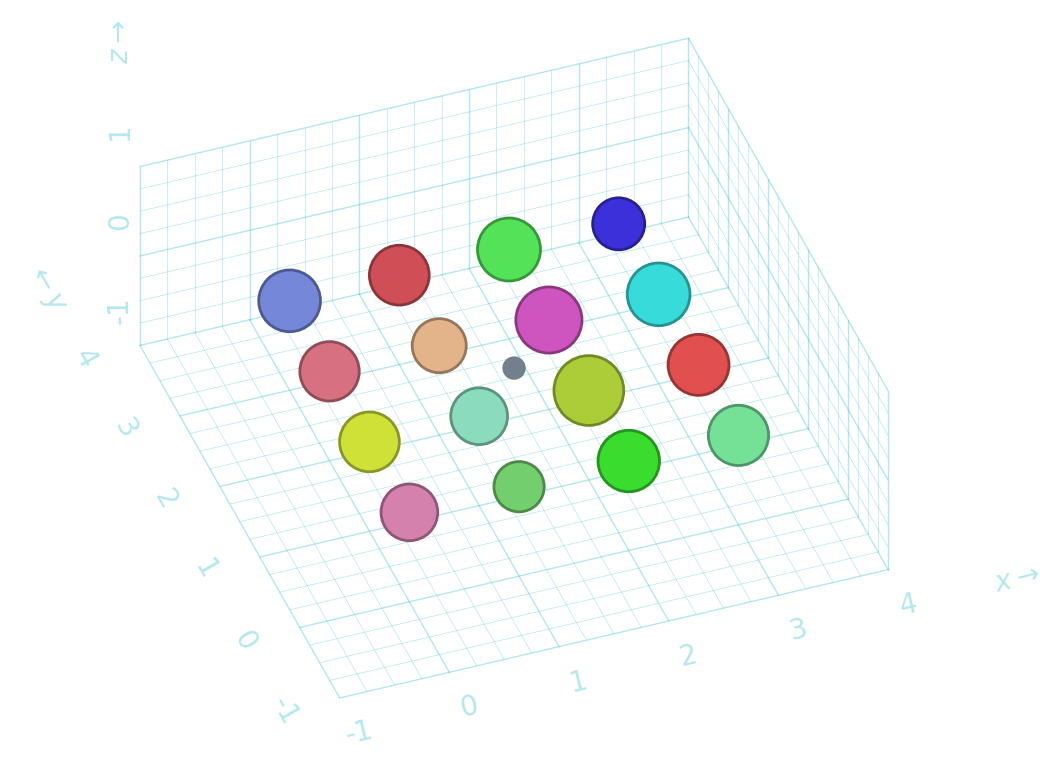

In [31]:
d = robodraw.Drawing()

coos = [(i, j, 0) for i in range(4) for j in range(4)]

for coo in coos:
    d.circle(
        coo,
        radius=np.random.uniform(0.2, 0.3),
        color=robodraw.hash_to_color(str(coo)),
    )

# dot is a simple alias circle
d.dot((1.5, 1.5, 0))

d.grid3d()

### Cubes

[`Drawing.cube`](robodraw.Drawing.cube) draws a cube with a given
`radius` and center coordinates, only for 3D coordinates.

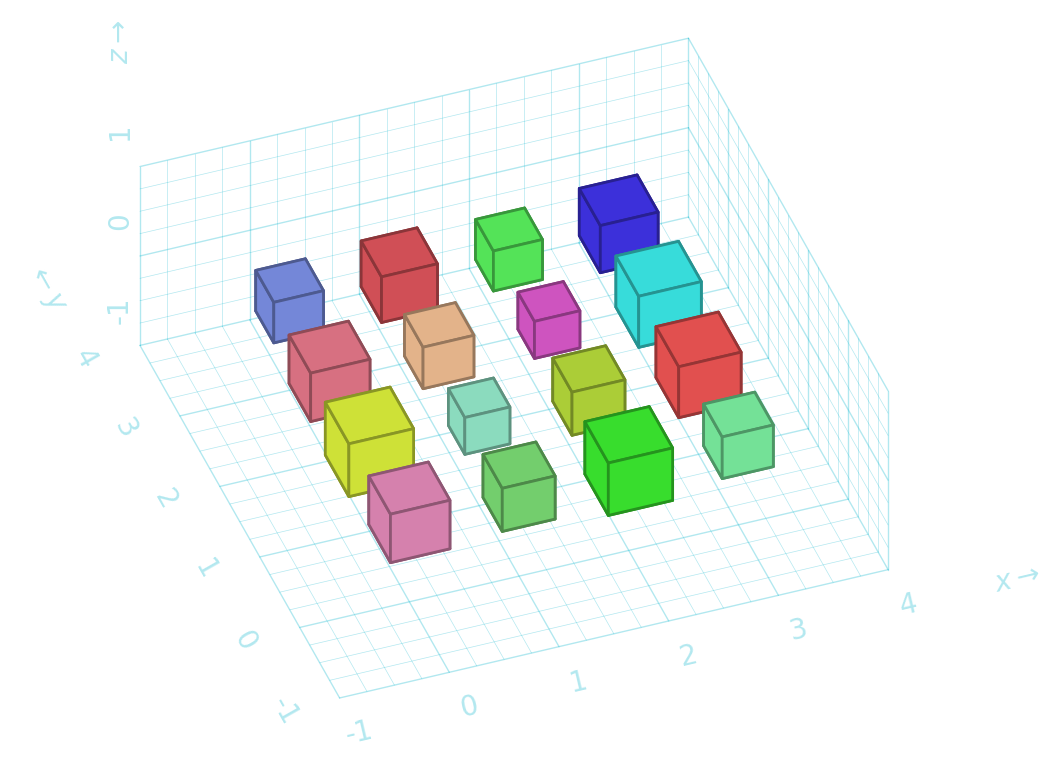

In [32]:
d = robodraw.Drawing()

coos = [(i, j, 0) for i in range(4) for j in range(4)]

for coo in coos:
    d.cube(
        coo,
        radius=np.random.uniform(0.2, 0.3),
        color=robodraw.hash_to_color(str(coo)),
    )

d.grid3d()

### Text

[`Drawing.text`](robodraw.Drawing.text) places text in data coordinates
(including 3D). [`Drawing.label_ax`](robodraw.Drawing.label_ax) and
[`Drawing.label_fig`](robodraw.Drawing.label_fig) are the same but default
to axis and figure coordinates respectively.

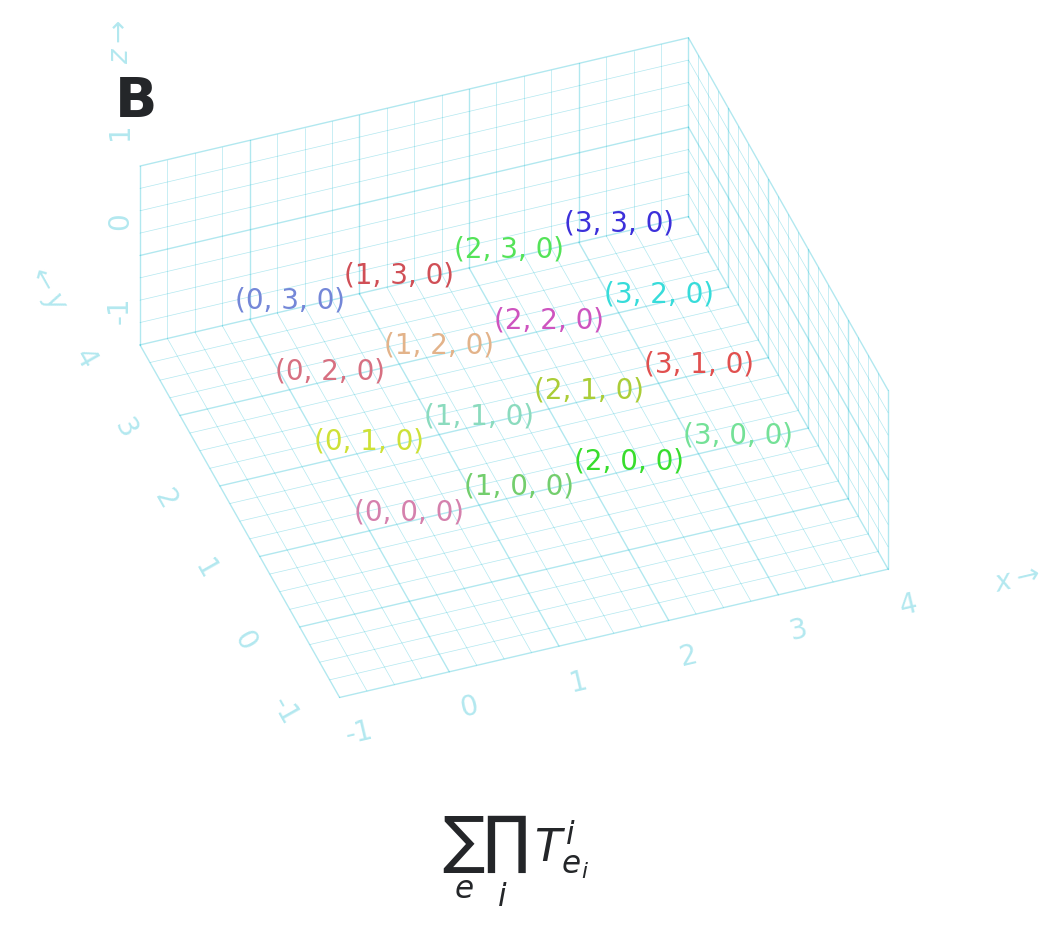

In [33]:
d = robodraw.Drawing()

coos = [(i, j, 0) for i in range(4) for j in range(4)]

for coo in coos:
    d.text(coo, str(coo), color=robodraw.hash_to_color(str(coo)))

# labels are the same but use the axes or figure coordinates
d.label_ax(0.1, 0.9, "$\\mathbf{B}$", fontsize=20)
d.label_fig(0.5, 0.0, "$\\sum_e \\prod_i ~ T^i_{e_i}$", fontsize=16)

d.grid3d()

### General shapes

[`Drawing.shape`](robodraw.Drawing.shape) draws a general filled shape
given a sequence of 2D or 3D coordinates.

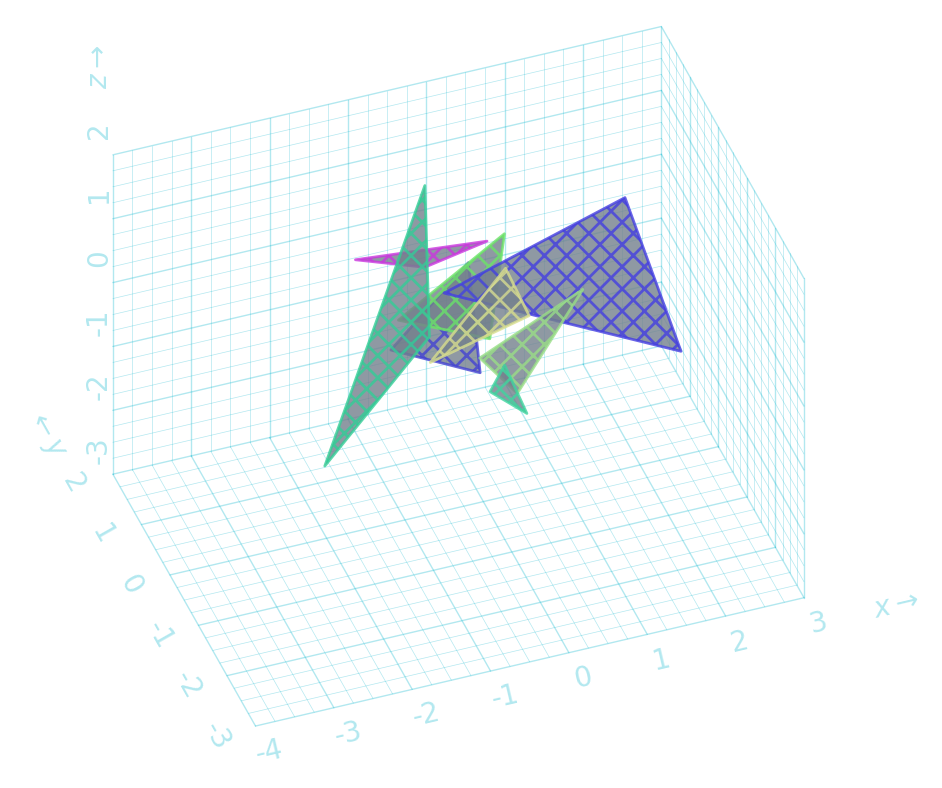

In [34]:
d = robodraw.Drawing()

rng = np.random.default_rng(1)
pts = rng.normal(size=(8, 3, 3))

for coos in pts:
    d.shape(
        coos,
        alpha=0.8,
        hatch="XXX",
        edgecolor=robodraw.hash_to_color(str(coos)),
    )

d.grid3d()

### Markers

[`Drawing.marker`](robodraw.Drawing.marker) is a convenience method for
specifying the shape of a patch using a single string or integer, to yield
a regular polygon.

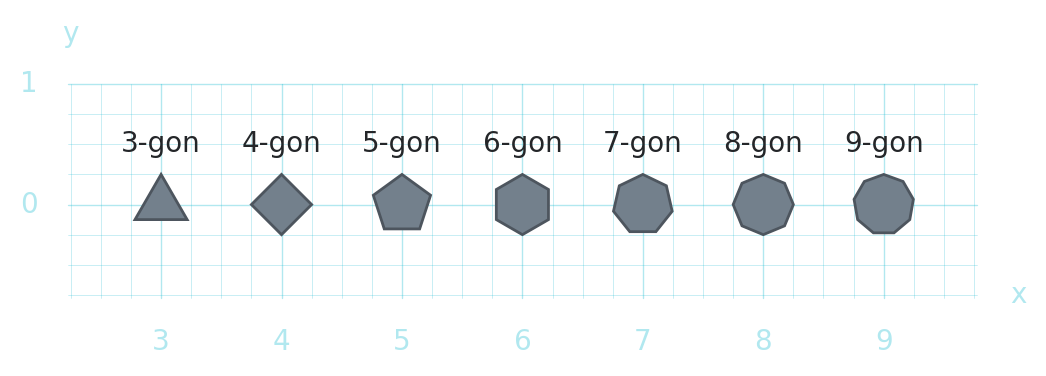

In [35]:
d = robodraw.Drawing()

for p in range(3, 10):
    d.marker((p, 0), marker=p)
    d.text((p, 0.5), f"{p}-gon")

d.grid()

It is a wrapper around [`Drawing.regular_polygon`](robodraw.Drawing.regular_polygon) with which you can also change the rotation with the `orientation` argument.

### Stars

The other class of markers are drawn using [`Drawing.star`](robodraw.Drawing.star), which you can call directly:

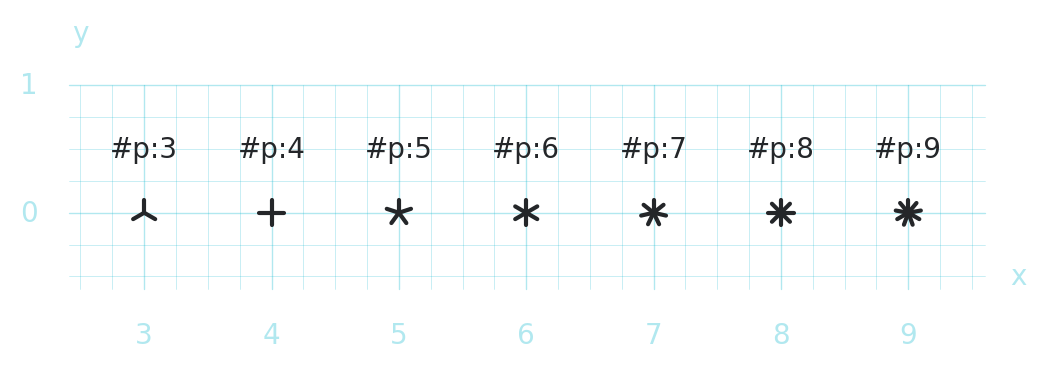

In [36]:
d = robodraw.Drawing()

for p in range(3, 10):
    d.star((p, 0), npoint=p)
    d.text((p, 0.5), f"#p:{p}")

d.grid()

You can specify the `radius` (in data units) and the orientation (in radians from vertical):

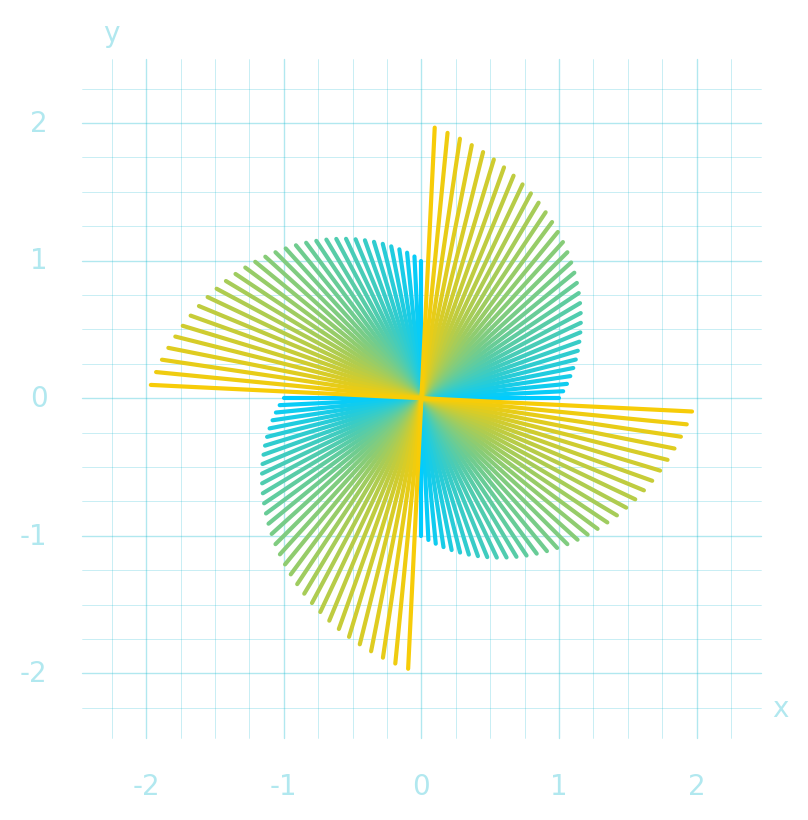

In [37]:
d = robodraw.Drawing()

K = 32

for i in range(0, K):
    radius = 1 + i / K
    orientation = i / K * np.pi / 2
    color = (i / K, 0.8, 1 - i / K)
    d.star(
        (0, 0), npoint=4, radius=radius, orientation=orientation, color=color
    )

d.grid()

The alias [`Drawing.cross`](robodraw.Drawing.cross) is shorthand for drawing a diagonal star with 4 points:

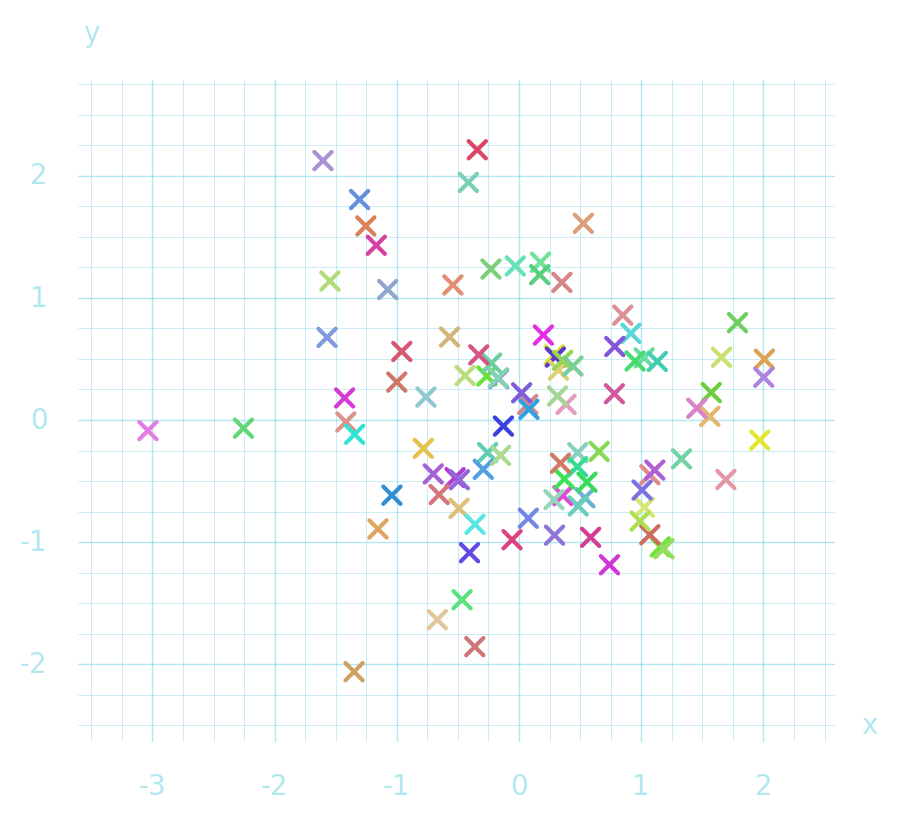

In [38]:
d = robodraw.Drawing()
coos = np.random.randn(100, 2)
for x, y in coos:
    d.cross((x, y), color=robodraw.hash_to_color(str((x, y))))
d.grid()

## Lines and curves

### Lines

The basic method for drawing lines between a pair of 2D or 3d points is
[`Drawing.line`](robodraw.Drawing.line).

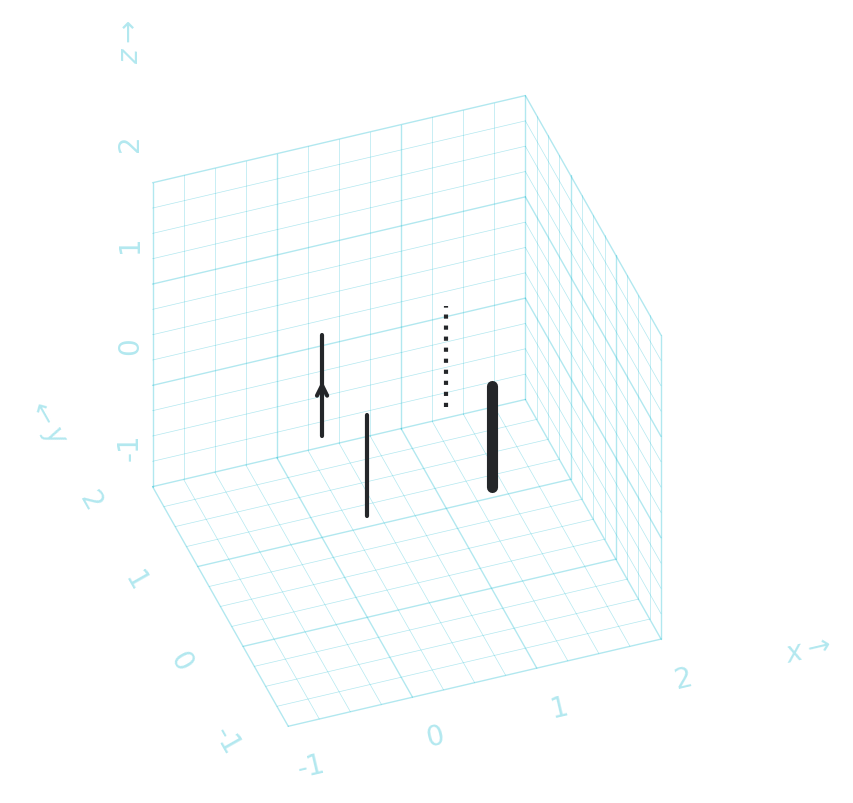

In [39]:
d = robodraw.Drawing()

d.line((0, 0, 0), (0, 0, 1))
d.line((0, 1, 0), (0, 1, 1), arrowhead=True)
d.line((1, 0, 0), (1, 0, 1), linewidth=4)
d.line((1, 1, 0), (1, 1, 1), linestyle=":")

d.grid3d()

When drawing lattice bonds it can be useful to shorten the lines somewhat for visual effect.

1. The `stretch` kwarg applies an overall relative stretch to the whole line.
2. The `shorten` kwarg makes the line stop an absolute amount shorter, a tuple can be used to control start and end separately.

By setting `shorten` to the `radius` of circles drawn, the lines connect exactly to the circle edge:

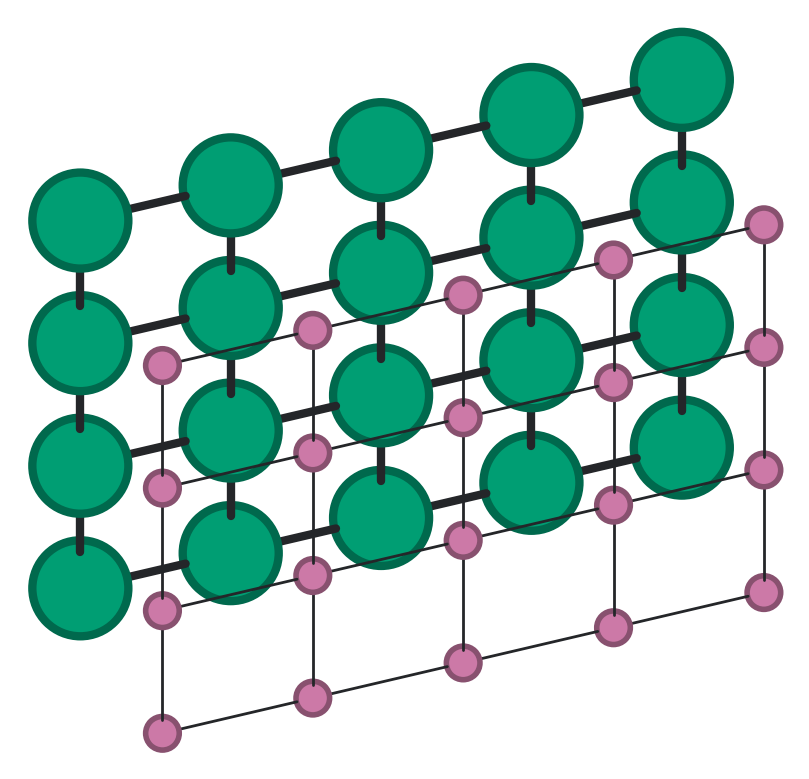

In [40]:
d = robodraw.Drawing()

r = 0.15

edges = [((i, j), (i, j + 1)) for i in range(5) for j in range(3)] + [
    ((i, j), (i + 1, j)) for i in range(4) for j in range(4)
]
sites = {site for edge in edges for site in edge}

for i, j in sites:
    d.circle(
        (i, 0, j),
        radius=2.0 * r,
        color=robodraw.get_color("green"),
        linewidth=3,
    )
    d.circle(
        (i, -1.5, j),
        radius=0.7 * r,
        color=robodraw.get_color("pink"),
        linewidth=2,
    )
for (ia, ja), (ib, jb) in edges:
    d.line((ia, 0, ja), (ib, 0, jb), shorten=2.0 * r, linewidth=3)
    d.line((ia, -1.5, ja), (ib, -1.5, jb), shorten=0.7 * r, linewidth=1)

### Arrows and labels

You can easily add text and arrows along lines:

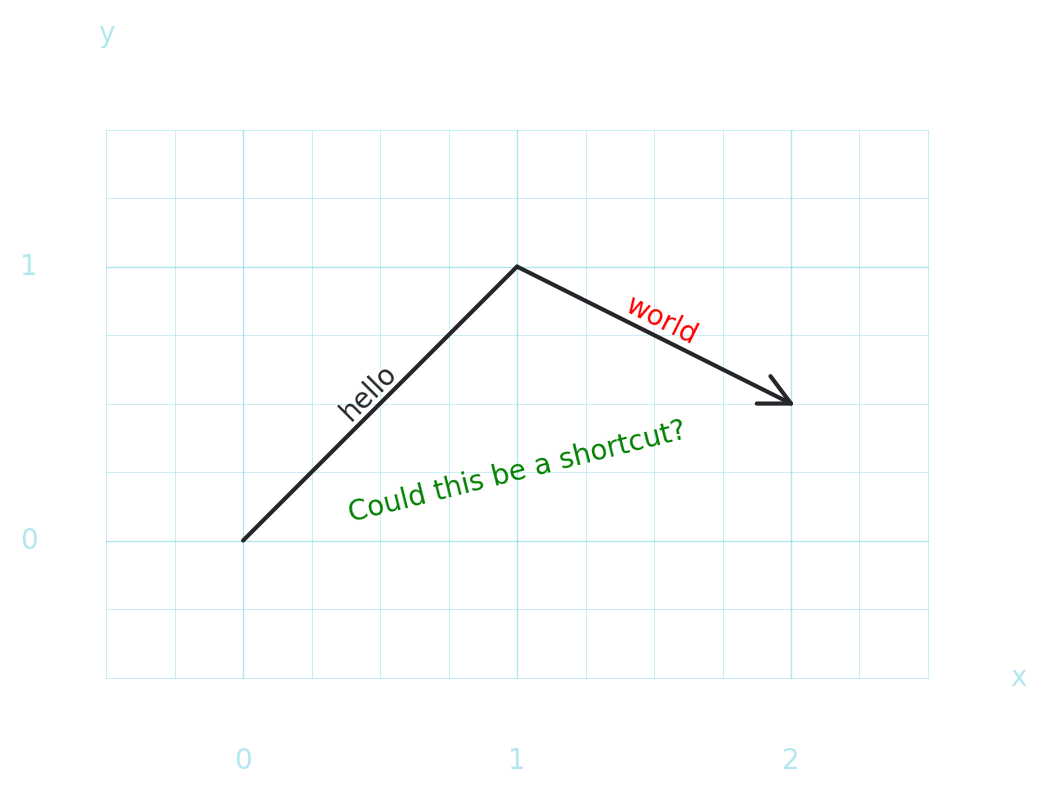

In [41]:
d = robodraw.Drawing()

pa, pb, pc = (0, 0), (1, 1), (2, 0.5)

d.line(pa, pb, text="hello\n")
d.line(
    pb, pc, text=dict(text="world\n", color="red"), arrowhead=dict(center=1)
)

# calling `line` with `text=` is a shortcut for `text_between`
d.text_between(pa, pc, "Could this be a shortcut?", color="green")
d.grid()

### Curves

If you want a line to pass through multiple points, you can use
[`Drawing.curve`](robodraw.Drawing.curve) to draw a smooth curve.

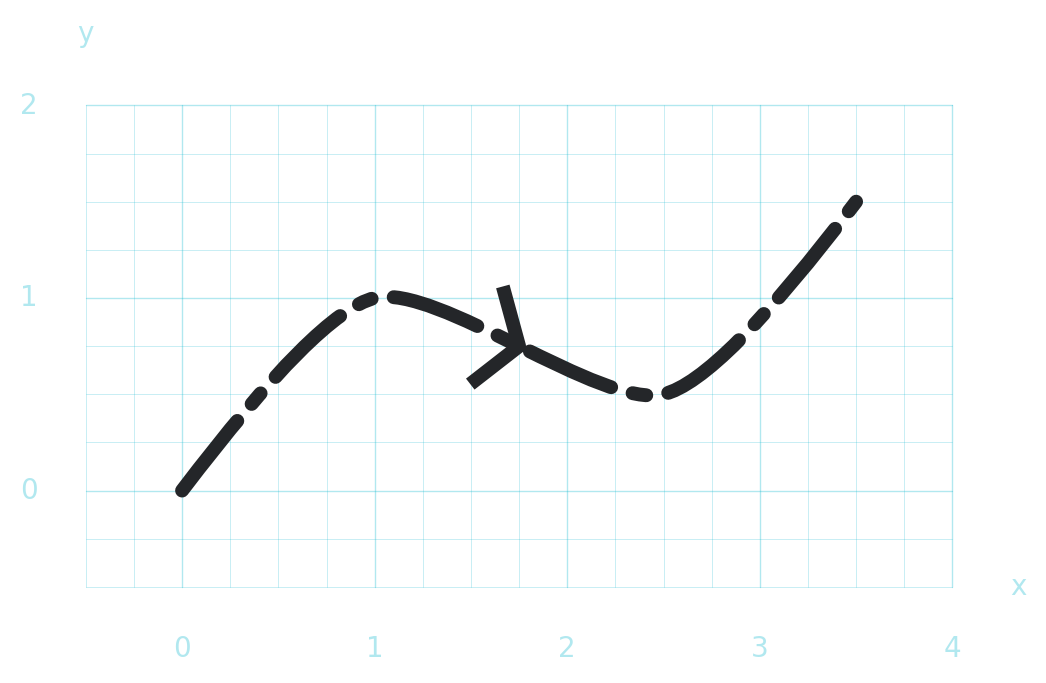

In [42]:
d = robodraw.Drawing()

d.curve(
    [(0, 0), (1, 1), (2.5, 0.5), (3.5, 1.5)],
    linestyle="-.",
    linewidth=5,
)

# you can draw just the arrowhead separately
d.arrowhead((1, 1), (2.5, 0.5), linewidth=5, width=0.15)

d.grid()

Curves pass *exactly* through all points given, with the `smoothing` kwarg controlling... how smoothly they do this.

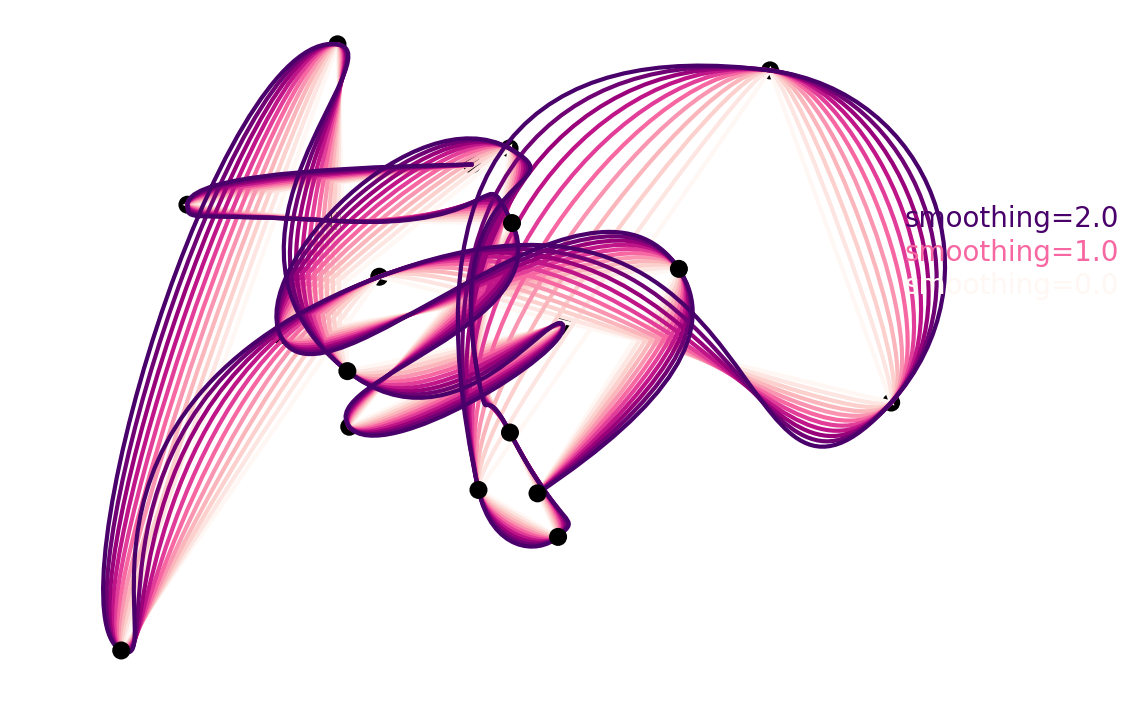

In [43]:
import matplotlib as mpl

d = robodraw.Drawing()

rng = np.random.default_rng(1)
pts = rng.normal(size=(20, 3))
cm = mpl.colormaps.get_cmap("RdPu")

for pt in pts:
    d.dot(pt, color="black", radius=0.05)

for smoothing in np.linspace(0.0, 2.0, 11):
    d.curve(pts, smoothing=smoothing, color=cm(smoothing / 2))

d.label_ax(1.0, 0.60, "smoothing=0.0", color=cm(0.0))
d.label_ax(1.0, 0.65, "smoothing=1.0", color=cm(0.5))
d.label_ax(1.0, 0.70, "smoothing=2.0", color=cm(1.0))

[`Drawing.curve`](robodraw.Drawing.curve) also takes the `shorten` kwarg which shortens the final segments by the specified absolute amount:

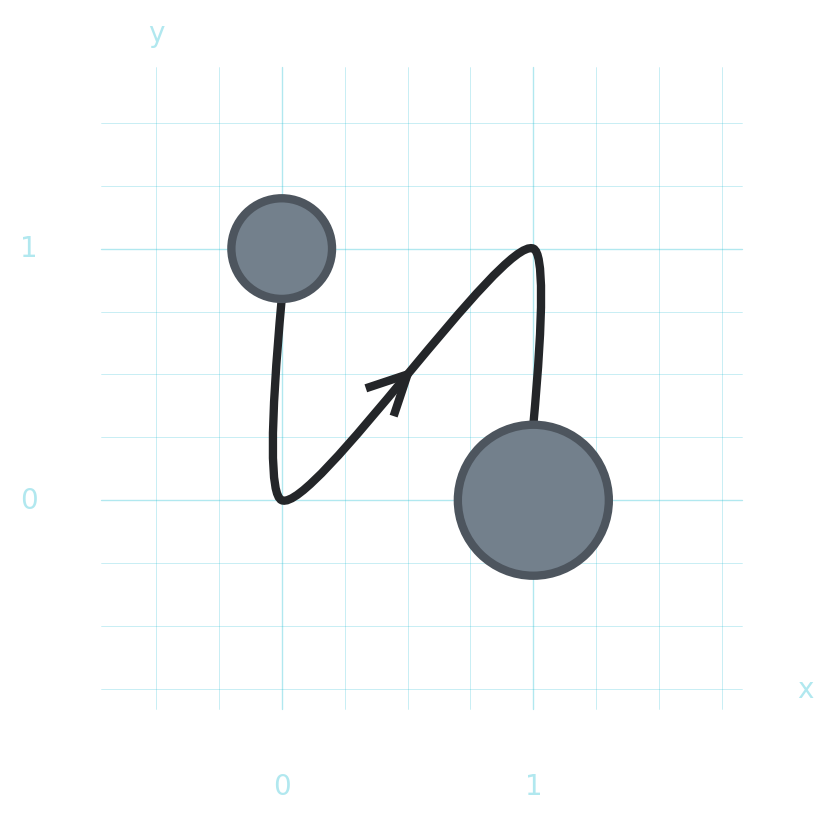

In [44]:
d = robodraw.Drawing()

r1 = 0.2
r2 = 0.3

d.circle((0, 1), radius=r1, linewidth=3)
d.curve([(0, 1), (0, 0), (1, 1), (1, 0)], shorten=(r1, r2), linewidth=3)
# also add an arrow on the middle segment
d.arrowhead((0, 0), (1, 1), linewidth=3)
d.circle((1, 0), radius=r2, linewidth=3)
d.grid()

### Bezier

If you want to draw a bezier curve by explicitly passing both the coordinates and the anchor points you can use [`Drawing.bezier`](robodraw.Drawing.bezier):

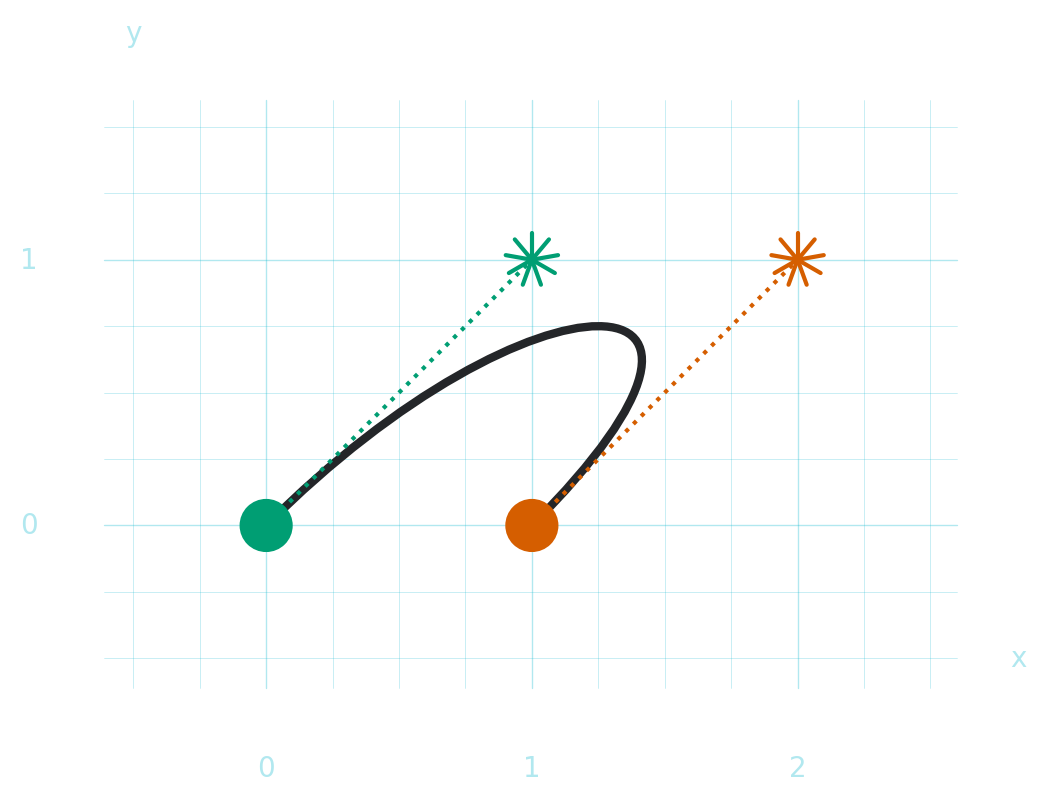

In [45]:
d = robodraw.Drawing()

cooa = (0, 0)
anca = (1, 1)
ancb = (2, 1)
coob = (1, 0)

d.bezier([cooa, anca, ancb, coob], linewidth=3)

d.dot(cooa, color=robodraw.get_color("green"))
d.star(anca, color=robodraw.get_color("green"))
d.line(cooa, anca, linestyle=":", color=robodraw.get_color("green"))

d.dot(coob, color=robodraw.get_color("red"))
d.star(ancb, color=robodraw.get_color("red"))
d.line(coob, ancb, linestyle=":", color=robodraw.get_color("red"))
d.grid()

You can supply any sequence of length 3N + 1 to draw a continuous line:

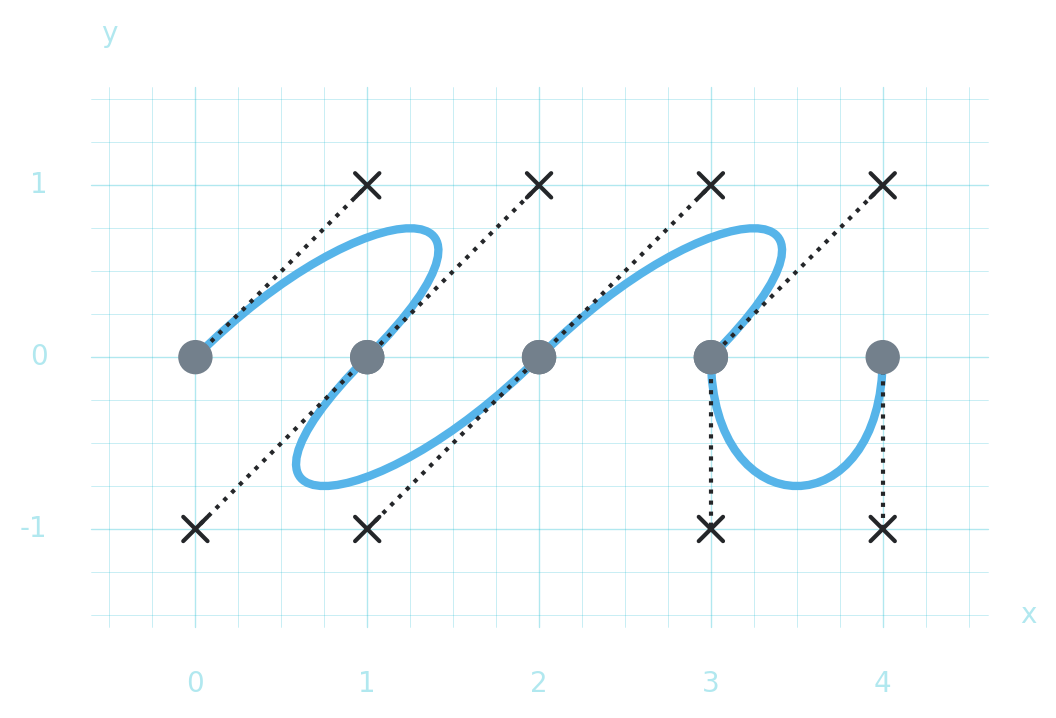

In [46]:
d = robodraw.Drawing()

coos = [
    (0, 0),
    (1, 1),
    (2, 1),  # control points
    (1, 0),
    (0, -1),
    (1, -1),  # control points
    (2, 0),
    (3, 1),
    (4, 1),  # control points
    (3, 0),
    (3, -1),
    (4, -1),  # control points
    (4, 0),
]
d.bezier(coos, linewidth=3, color=robodraw.get_color("blue"))

for i in range(0, len(coos) - 1, 3):
    d.dot(coos[i])
    d.dot(coos[i + 3])
    d.cross(coos[i + 1])
    d.cross(coos[i + 2])
    d.line(coos[i], coos[i + 1], linestyle=":")
    d.line(coos[i + 2], coos[i + 3], linestyle=":")

d.grid()

### Multi-edges

If you want to programmatically draw multiple lines from one place to the other ('multi-edges') you can use [`Drawing.line_offset`](robodraw.Drawing.line_offset):

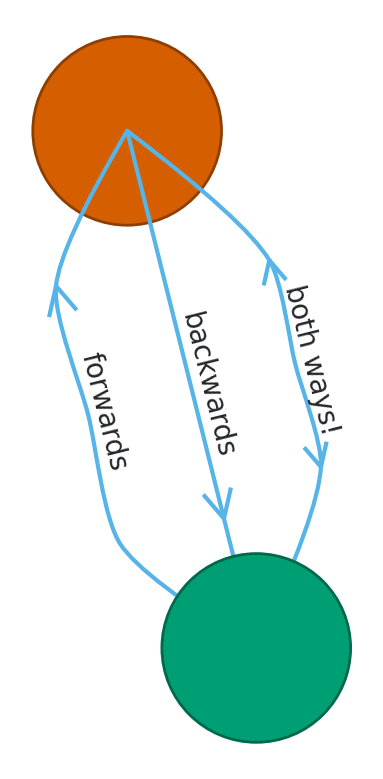

In [47]:
d = robodraw.Drawing()

pa, pb = (0, 0, 0), (0, 1, 1)

green = robodraw.get_color("green")
red = robodraw.get_color("red")
blue = robodraw.get_color("blue")

d.circle(pa, color=green)
d.circle(pb, color=red)

# you can still use arrowheads and text labels
d.line_offset(
    pa, pb, 0.2, arrowhead=dict(center=0.9), text="forwards\n", color=blue
)
d.line_offset(
    pa,
    pb,
    0.0,
    arrowhead=dict(center=0.9, reverse=True),
    text="backwards\n",
    color=blue,
)
d.line_offset(
    pa,
    pb,
    -0.2,
    arrowhead=dict(center=0.9, reverse="both"),
    text="both ways!\n",
    color=blue,
    midlength=0.4,
)

### zigzags

[`Drawing.zigzag`](robodraw.Drawing.zigzag) is similar to [`Drawing.line`](robodraw.Drawing.line), but creates a zigzag pattern instead of a straight line, which can be useful to differentiate beyond `linestyle`.

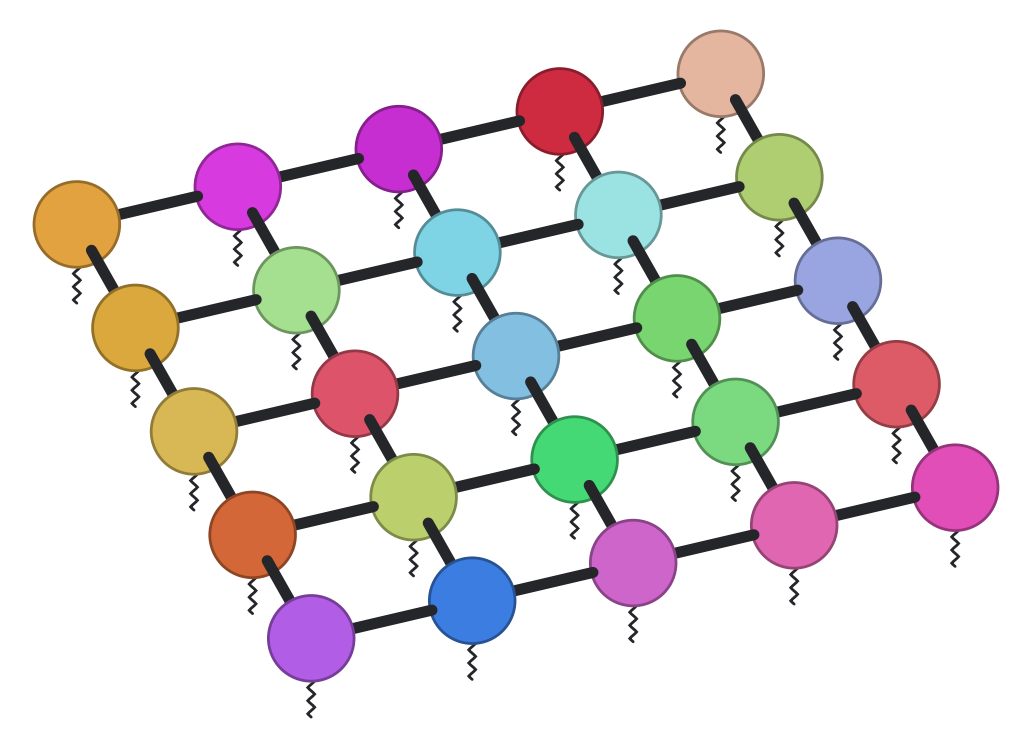

In [48]:
d = robodraw.Drawing()

for i in range(5):
    for j in range(5):
        d.circle((i, j, 1), color=robodraw.hash_to_color(str((i, j))))
        if i < 4:
            d.line((i, j, 1), (i + 1, j, 1), linewidth=4, shorten=0.25)
        if j < 4:
            d.line((i, j, 1), (i, j + 1, 1), linewidth=4, shorten=0.25)

        d.zigzag((i, j, 1), (i, j, 0.4), linewidth=1, width=0.02)

You can control:
- `smoothing`: how smooth the zigzagging is (0 = sharp corners, 1 = very smooth)
- `extend`: only start zigzagging after this length
- `width`: the width of the zigzag line, by default aims for 8 zigzags

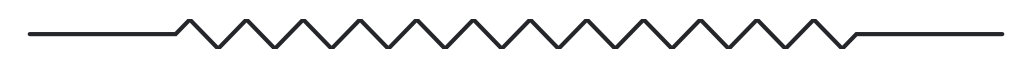

In [49]:
d = robodraw.Drawing()
d.zigzag((0, 0), (2, 0), smoothing=0.0, extend=0.3, width=0.03)

## Highlighting areas and groups of objects

### Patches around general areas

In technical drawings it is often useful to highlight areas. The
[`Drawing.patch`](robodraw.Drawing.patch) method does this by filling in
a curve, given by a sequence of 2D or 3D coordinates.

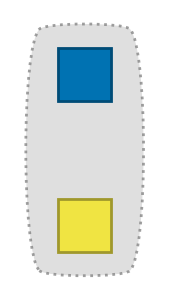

In [50]:
d = robodraw.Drawing()

d.marker((0, 0), marker="s", color=robodraw.get_color("yellow"))
d.marker((0, 1), marker="s", color=robodraw.get_color("bluedark"))
d.patch(
    [
        (-0.3, -0.3),
        (+0.3, -0.3),
        (+0.3, +1.3),
        (-0.3, +1.3),
    ],
    smoothing=0.3,
)
d.scale_figsize()

### Patches around two circles

If you want to specifically highlight two circles, you can use
[`Drawing.patch_around_circles`](robodraw.Drawing.patch_around_circles),
and simply specify the two circles by their center coordinates and radii.

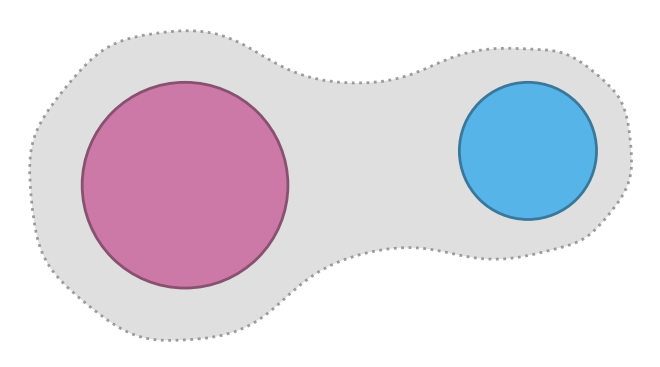

In [51]:
d = robodraw.Drawing(figsize=(4, 4))

d.circle((0, 0), radius=3, color=robodraw.get_color("pink"))
d.circle((10, 1), radius=2, color=robodraw.get_color("blue"))

d.patch_around_circles(
    (0, 0),
    3,
    (10, 1),
    2,
    padding=0.5,
)

### Patches around arbitrary collections of objects

If you want to highlight an arbitrary collection of objects, you can call
[`Drawing.patch_around`](robodraw.Drawing.patch_around), this computes
the convex hull of the objects and draws a patch around it.

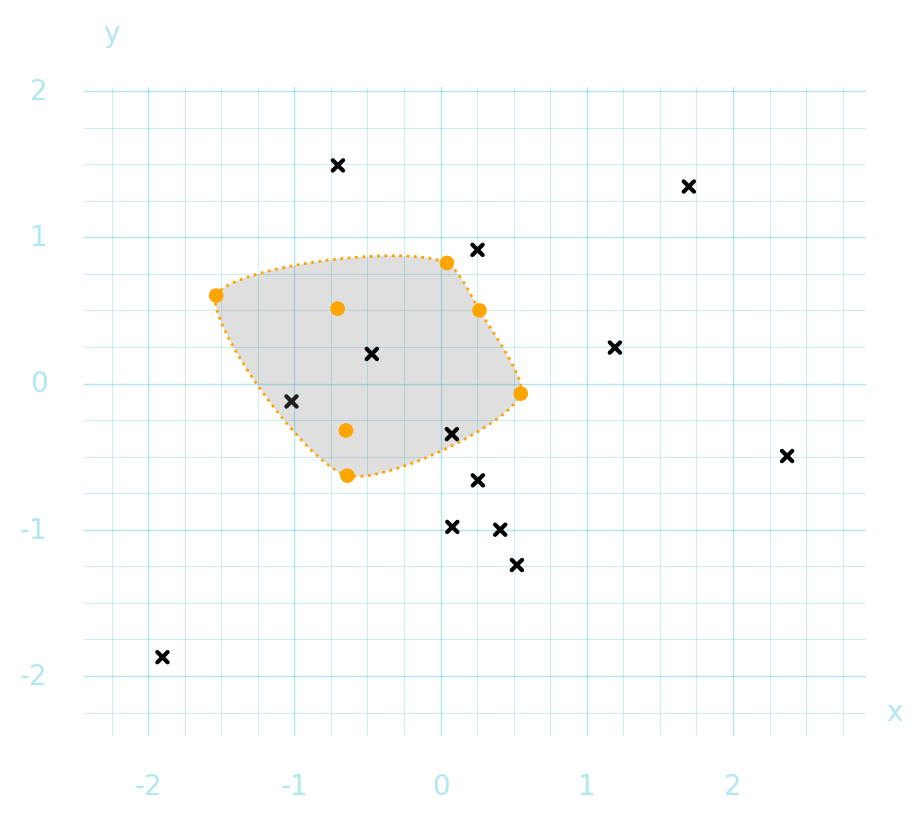

In [52]:
d = robodraw.Drawing()

for pt in pts[:7]:
    d.dot(pt, color="orange", radius=0.05)
for pt in pts[7:]:
    d.cross(pt, color="black", radius=0.05)

d.patch_around(pts[:7], edgecolor="orange")
d.grid()

You can control how much padding is added around the perimeter of the objects
using the `radius` kwarg.

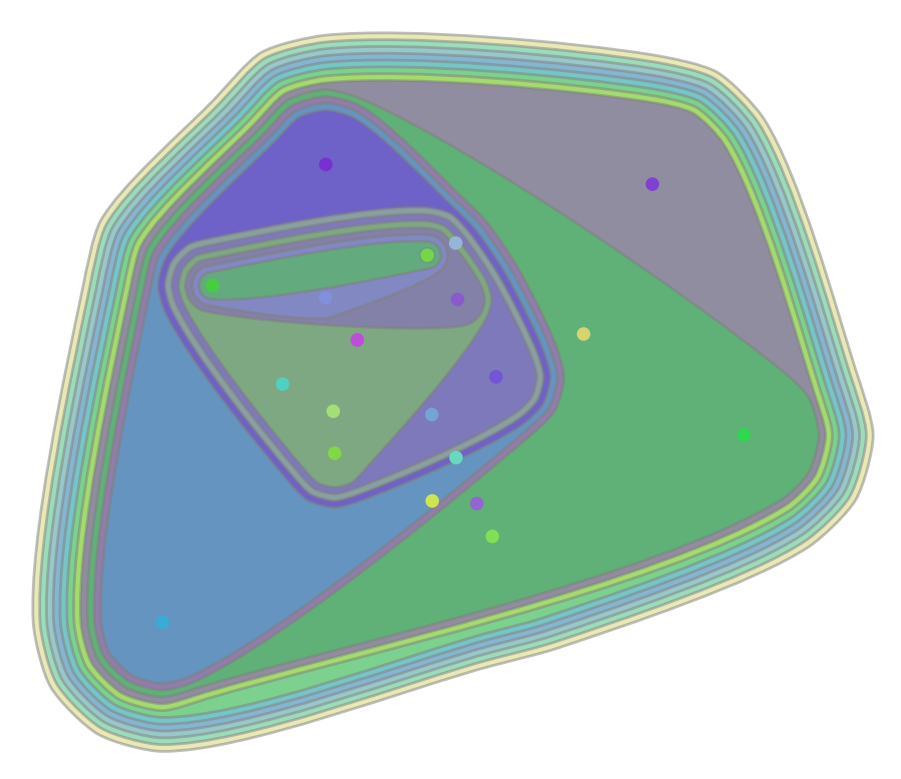

In [53]:
d = robodraw.Drawing()

for k, pt in enumerate(pts):
    d.dot(pt, color=robodraw.hash_to_color(str(k)), radius=0.05)

for k in range(1, len(pts)):
    d.patch_around(
        pts[:k],
        radius=0.05 * k,
        facecolor=robodraw.hash_to_color(str(k - 1)),
        linestyle="-",
        zorder=-k,
        alpha=0.5,
    )